# Topic Modeling with Latent Dirichlet Allocation (LDA)

## Step 1: Load Data

In [1]:
# Import libraries
import numpy as np
import pandas as pd
from plotnine import *
import warnings
warnings.filterwarnings('ignore')

# Use sklearn for dataset and text processing
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Load a subset of the 20 newsgroups dataset (3 categories)
categories = [
    'rec.sport.baseball',
    'talk.politics.guns',
    'sci.space'
]

# Fetch the dataset, removing headers/footers/quotes for cleaner text
newsgroups = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

# Extract documents and create labels mapping
documents = newsgroups.data
category_names = newsgroups.target_names

# Check results
print(f"Number of documents: {len(documents)}")
print(f"Categories: {category_names}")
print(f"\nSample document:\n{documents[0][:250]}...")

Number of documents: 2891
Categories: ['rec.sport.baseball', 'sci.space', 'talk.politics.guns']

Sample document:

This activity is regularly reported in Ron's interesting posts. Could
someone explain what the Command Loss Timer is?

Thanks, Alan...


## Step 2: Text Preprocessing

In [3]:
# Create a CountVectorizer to convert documents into a matrix of token counts
# This is required for LDA, which expects count data (not TF-IDF)
vectorizer = CountVectorizer(
    max_df=0.95,          # Ignore words with very high frequency (appear in > 95% of documents)
    min_df=0.01,          # Ignore words with very low frequency (appear in < 1% documents)
    max_features=1000,    # Limit to top 1000 features
    stop_words='english', # Remove English stop words
    lowercase=True        # Lowercase text
)

# Transform documents into document-term matrix
doc_term_matrix = vectorizer.fit_transform(documents)

# Extract feature names (vocabulary)
feature_names = vectorizer.get_feature_names_out()

# Check results
print(f"Document-term matrix shape: {doc_term_matrix.shape}")
print(f"Number of unique terms: {len(feature_names)}")

Document-term matrix shape: (2891, 1000)
Number of unique terms: 1000


## Step 3: Build and Train the LDA Model

In [4]:
# Initialize LDA model, specifying the number of topics to discover (3, to match the 3 categories loaded)
# LDA assumes that each document is a mixture of topics and each topic is a mixture of words.
n_topics = 3

lda_model = LatentDirichletAllocation(
    n_components=n_topics,      # Number of topics to extract
    max_iter=20,                # Maximum iterations for convergence
    learning_method='online',   # Use online variational Bayes
    random_state=42,            # Set random state for reproducibility
    batch_size=128,             # Number of documents to use in each iteration  
    evaluate_every=-1,          # Don't evaluate perplexity (faster training)
    n_jobs=-1                   # Use all available CPU cores
)

# Fit the model to the document-term matrix
print("Training LDA model...")
lda_output = lda_model.fit_transform(doc_term_matrix)

# Check results
print(f"\nTraining complete! LDA output shape: {lda_output.shape}")
print(f"Each document is now represented as a distribution over {n_topics} topics")

Training LDA model...

Training complete! LDA output shape: (2891, 3)
Each document is now represented as a distribution over 3 topics


## Step 4: Examine the Discovered Topics

In [5]:
def display_topics(
    model: LatentDirichletAllocation,
    feature_names: np.ndarray,
    n_top_words: int = 10
) -> None:
    """
    Display the top words for each topic discovered by the LDA model.
    
    Parameters:
    model (LatentDirichletAllocation): Trained LDA model containing topic-word distributions.
    feature_names (np.ndarray): Array of feature names (vocabulary) from the vectorizer.
    n_top_words (int): Number of top words to display per topic (default: 10).
    
    Returns:
    None: Prints the topics and their top words to stdout.
    """
    for topic_idx, topic in enumerate(model.components_):
        # Get indices of top words, sorted by weight in descending order
        top_indices = topic.argsort()[-n_top_words:][::-1]
        # Extract the actual word strings using the indices
        top_words = [feature_names[i] for i in top_indices]
        # Print topic number and its top words as comma-separated list
        print(f"\nTopic {topic_idx + 1}:")
        print(", ".join(top_words))

# Display discovered topics
print("DISCOVERED TOPICS:")
display_topics(lda_model, feature_names, n_top_words=10)

DISCOVERED TOPICS:

Topic 1:
people, gun, don, just, like, think, right, know, guns, time

Topic 2:
space, nasa, earth, launch, shuttle, orbit, data, 00, moon, new

Topic 3:
year, game, don, team, good, think, games, hit, baseball, like


## Step 5: Visualize Topic Distributions

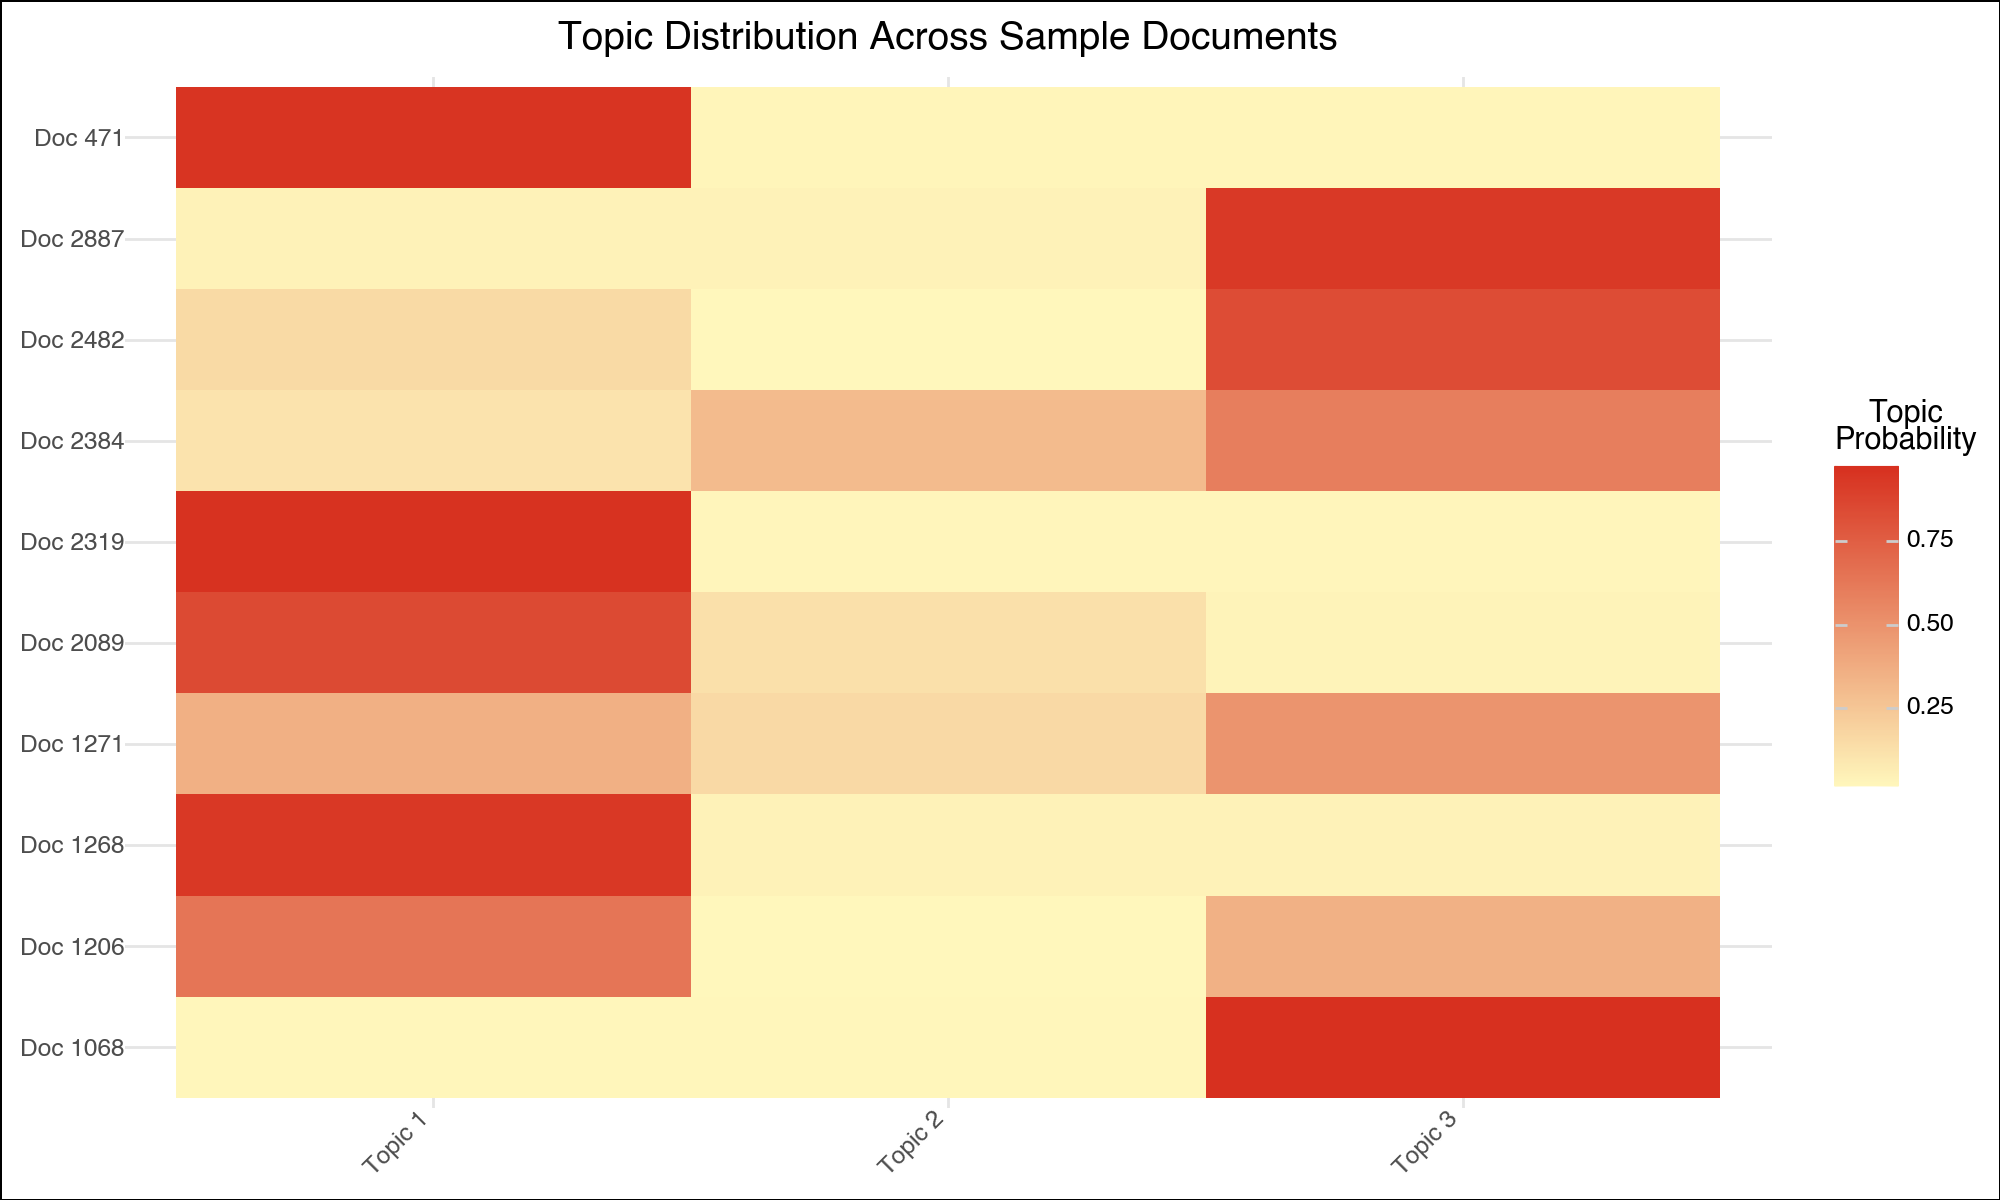

In [6]:
# Create a heatmap showing topic distribution for a sample of documents
n_docs_to_show = 10
sample_indices = np.random.choice(len(documents), n_docs_to_show, replace=False)

# Prepare data for plotnine heatmap
heatmap_data = pd.DataFrame(
    lda_output[sample_indices],
    columns=[f'Topic {i+1}' for i in range(n_topics)]
)
heatmap_data['Document'] = [f'Doc {i}' for i in sample_indices]
heatmap_long = heatmap_data.melt(
    id_vars='Document',
    var_name='Topic',
    value_name='Probability'
)

# Create heatmap using geom_tile
plot = (
    ggplot(heatmap_long, aes(x='Topic', y='Document', fill='Probability'))
    + geom_tile()
    + scale_fill_gradient(low='#FFF7BC', high='#D7301F', name='Topic\nProbability')
    + labs(
        title='Topic Distribution Across Sample Documents',
        x='',
        y=''
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        axis_text_x=element_text(rotation=45, hjust=1),
        plot_title=element_text(size=14, weight='bold'),
        plot_background=element_rect(fill='white'),
        panel_background=element_rect(fill='white')
    )
)

# Display plot
display(plot)